# Amazon India Sales & GST Analytics (Mar–Jun 2022)

**Goal:** turn ~1.29 lakh raw Amazon India apparel order lines into answers a business and its accounts team can act on:

1. How much did we really sell (after cancellations and returns), and is it growing?
2. Which categories and states drive revenue?
3. Where are we losing orders (cancellations, returns), and does fulfilment method matter?
4. What is our estimated GST liability, by rate slab and by CGST / SGST / IGST?

**Tools:** Python (Pandas, Matplotlib) · SQL (SQLite, see `sql/`) · Excel (see `excel/`) · interactive dashboard (see `docs/`)

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import clean_data as cd

IMG = ROOT / "images"; IMG.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Chart style: one blue for single series, recessive grid
BLUE, ORANGE, INK, MUTED, GRID, SURFACE = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e", "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "figure.dpi": 110, "axes.axisbelow": True, "savefig.bbox": "tight", "font.size": 10,
})
def inr_lakh(x, _=None):  # format rupees as lakh
    return f"₹{x/1e5:,.0f}L"



## 1. Load raw data & check quality

In [2]:
raw = cd.load_raw()
print(raw.shape)
raw.head(3)

(128975, 24)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN


In [3]:
quality = pd.DataFrame({
    "missing": raw.isna().sum(),
    "missing_%": (raw.isna().mean() * 100).round(2),
}).query("missing > 0").sort_values("missing", ascending=False)
print("Exact duplicate rows:", raw.drop(columns=["index"]).duplicated().sum())
print("Raw status values:", raw["Status"].nunique())
print("Raw state spellings:", raw["ship-state"].str.strip().str.upper().nunique())
quality

Exact duplicate rows: 6
Raw status values: 13


Raw state spellings: 47


,missing,missing_%
fulfilled-by,89698,69.55
promotion-ids,49153,38.11
Unnamed: 22,49050,38.03
currency,7795,6.04
Amount,7795,6.04
Courier Status,6872,5.33
ship-postal-code,33,0.03
ship-state,33,0.03
ship-city,33,0.03
ship-country,33,0.03


**Issues found**

* `Amount` is missing on ~6% of rows — almost all of them **cancelled** orders (nothing was charged), so they are set to 0, not dropped.
* 13 different order statuses → grouped into 5 business groups (Shipped/Delivered, Cancelled, Returned, Pending, Lost/Damaged).
* State names have typos and abbreviations (`RAJSHTHAN`, `RJ`, `ORISSA`, `NEW DELHI`, `PB` …) → standardised.
* 6 exact duplicate rows → removed. Two fully empty / free-text columns → dropped (kept a simple *has_promotion* flag).
* Date is text in `MM-DD-YY` format → converted to a real date.

## 2. Clean & enrich (logic lives in `src/clean_data.py`)

In [4]:
df = cd.clean(raw)
print(f"{len(raw):,} raw rows -> {len(df):,} clean rows")
print("States after cleanup:", df.ship_state.nunique())
df[["order_id","order_date","category","qty","amount","status_group","ship_state","gst_rate","taxable_value","gst_amount","supply_type"]].head()

128,975 raw rows -> 128,969 clean rows
States after cleanup: 37


,order_id,order_date,category,qty,amount,status_group,ship_state,gst_rate,taxable_value,gst_amount,supply_type
0,405-8078784-5731545,2022-04-30,Set,0,647.62,Cancelled,MAHARASHTRA,0.05,616.78,30.84,Intra-state
1,171-9198151-1101146,2022-04-30,Kurta,1,406.00,Shipped/Delivered,KARNATAKA,0.05,386.67,19.33,Inter-state
2,404-0687676-7273146,2022-04-30,Kurta,1,329.00,Shipped/Delivered,MAHARASHTRA,0.05,313.33,15.67,Intra-state
3,403-9615377-8133951,2022-04-30,Western Dress,0,753.33,Cancelled,PUDUCHERRY,0.05,717.46,35.87,Inter-state
4,407-1069790-7240320,2022-04-30,Top,1,574.00,Shipped/Delivered,TAMIL NADU,0.05,546.67,27.33,Inter-state


**Definition used everywhere:** *Net sales* = order lines that were **shipped or delivered**, with quantity ≥ 1 and amount > 0
(cancelled, returned, pending and lost orders are excluded).

In [5]:
net = df[df.is_net_sale]
kpi = pd.Series({
    "Order lines (all)": len(df),
    "Net sales (₹)": net.amount.sum(),
    "Net orders": net.order_id.nunique(),
    "Units sold": net.qty.sum(),
    "Avg order value (₹)": net.groupby("order_id").amount.sum().mean(),
    "Cancellation rate (%)": (df.status_group == "Cancelled").mean() * 100,
    "Return rate (%)": (df.status_group == "Returned").mean() * 100,
    "Estimated GST (₹)": net.gst_amount.sum(),
})
kpi.to_frame("value")

,value
Order lines (all),"128,969.00"
Net sales (₹),"69,660,658.00"
Net orders,"97,965.00"
Units sold,"105,484.00"
Avg order value (₹),711.08
Cancellation rate (%),14.21
Return rate (%),1.64
Estimated GST (₹),"4,167,667.98"


## 3. Sales trend

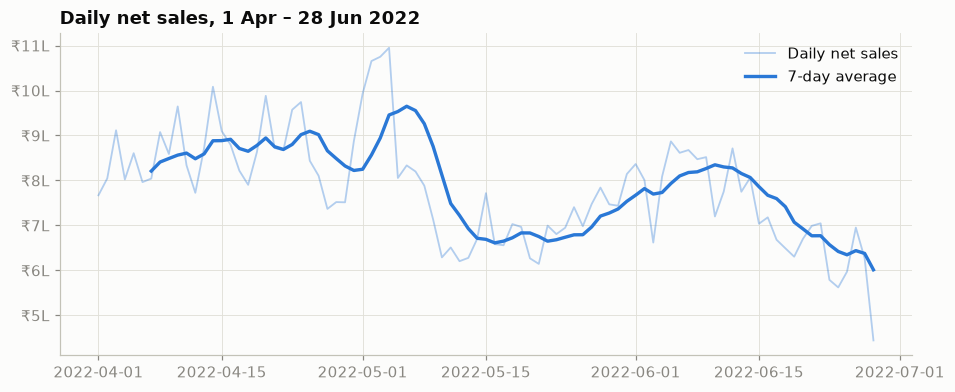

,net_sales,orders,days,sales_per_day,mom_change_%
order_month,,,,,
2022-04,"25,668,848.00",37410,30,"855,628.27",NaN
2022-05,"23,464,291.00",32293,31,"756,912.61",-8.60
2022-06,"20,317,741.00",27961,28,"725,633.61",-13.40


In [6]:
# 31 Mar (1 day) and 29 Jun (partial last day) are excluded from trend analysis
trend = net[(net.order_date >= "2022-04-01") & (net.order_date <= "2022-06-28")]
daily = trend.groupby("order_date").amount.sum()
roll = daily.rolling(7).mean()
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(daily.index, daily.values, color=BLUE, alpha=.35, lw=1.2, label="Daily net sales")
ax.plot(roll.index, roll.values, color=BLUE, lw=2.2, label="7-day average")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(inr_lakh))
ax.set_title("Daily net sales, 1 Apr – 28 Jun 2022")
ax.legend(frameon=False, loc="upper right")
fig.savefig(IMG / "01_daily_sales.png"); plt.show()

monthly = trend.groupby("order_month").agg(
    net_sales=("amount", "sum"), orders=("order_id", "nunique"), days=("order_date", "nunique"))
monthly["sales_per_day"] = monthly.net_sales / monthly.days
monthly["mom_change_%"] = (monthly.net_sales.pct_change() * 100).round(1)
monthly

*The data has only one day of March (31 Mar) and a partial last day (29 Jun), so trends use 1 Apr – 28 Jun. The per-day column keeps months of different length comparable.*

## 4. Category performance

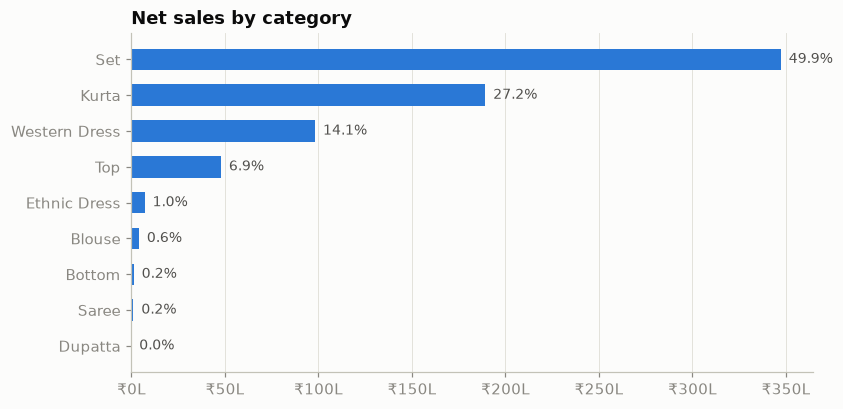

,net_sales,units,share_%
category,,,
Set,"34,733,734.00",40783,49.86
Kurta,"18,930,111.00",40785,27.17
Western Dress,"9,828,746.00",12683,14.11
Top,"4,795,739.00",8986,6.88
Ethnic Dress,"715,351.00",961,1.03
Blouse,"409,494.00",774,0.59
Bottom,"132,872.00",364,0.19
Saree,"113,696.00",145,0.16
Dupatta,915.00,3,0.00


In [7]:
cat = net.groupby("category").agg(net_sales=("amount","sum"), units=("qty","sum")).sort_values("net_sales")
cat["share_%"] = cat.net_sales / cat.net_sales.sum() * 100
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cat.index, cat.net_sales, color=BLUE, height=.6)
for y, (v, s) in enumerate(zip(cat.net_sales, cat["share_%"])):
    ax.text(v, y, f"  {s:.1f}%", va="center", fontsize=9, color="#52514e")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(inr_lakh)); ax.grid(axis="y", visible=False)
ax.set_title("Net sales by category")
fig.savefig(IMG / "02_category_sales.png"); plt.show()
cat.sort_values("net_sales", ascending=False)

## 5. Where are customers? (state-wise)

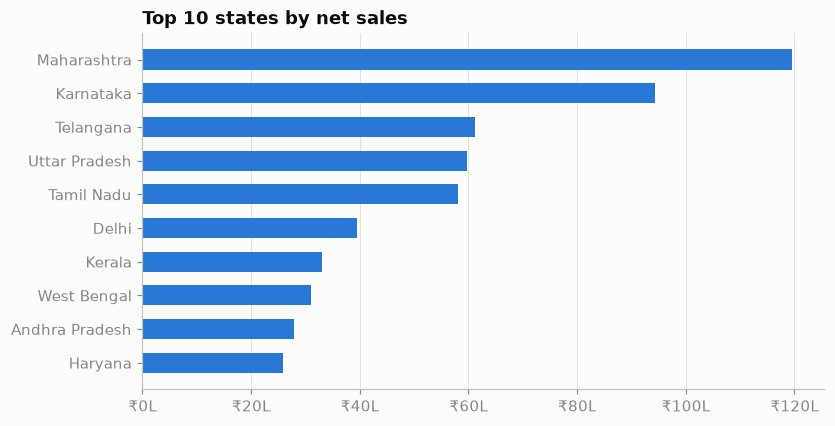

Top 5 states = 56.4% of net sales


,net_sales,orders,share_%,cum_share_%
ship_state,,,,
MAHARASHTRA,"11,954,553.00",17177,17.16,17.16
KARNATAKA,"9,436,223.00",13456,13.55,30.71
TELANGANA,"6,123,778.00",8520,8.79,39.50
UTTAR PRADESH,"5,968,450.00",8004,8.57,48.07
TAMIL NADU,"5,812,085.00",8682,8.34,56.41
DELHI,"3,950,397.00",5434,5.67,62.08
KERALA,"3,301,081.00",4822,4.74,66.82
WEST BENGAL,"3,096,107.00",4545,4.44,71.26
ANDHRA PRADESH,"2,796,932.00",3975,4.02,75.28


In [8]:
state = net.groupby("ship_state").agg(net_sales=("amount","sum"), orders=("order_id","nunique")).sort_values("net_sales", ascending=False)
state["share_%"] = state.net_sales / state.net_sales.sum() * 100
state["cum_share_%"] = state["share_%"].cumsum()
top10 = state.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(top10.index.str.title(), top10.net_sales, color=BLUE, height=.6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(inr_lakh)); ax.grid(axis="y", visible=False)
ax.set_title("Top 10 states by net sales")
fig.savefig(IMG / "03_top_states.png"); plt.show()
print(f"Top 5 states = {state['share_%'].head(5).sum():.1f}% of net sales")
state.head(10)

## 6. Cancellations & returns

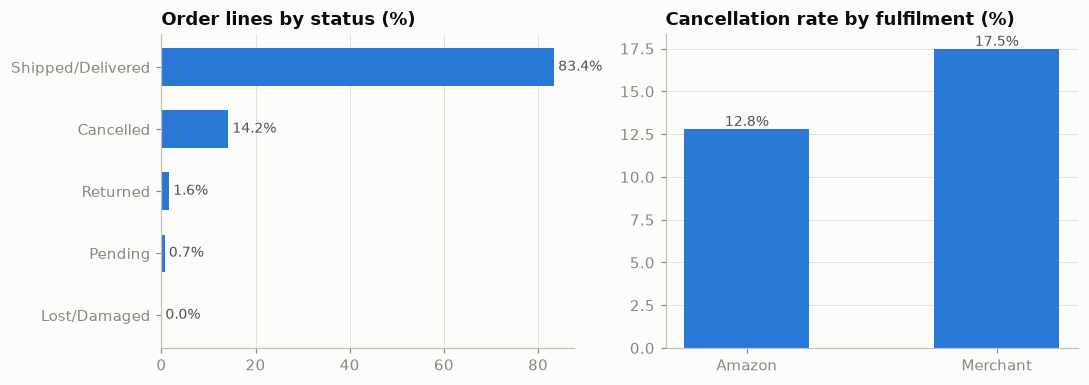

,cancellation_%
fulfilment,
Amazon,12.79
Merchant,17.47


In [9]:
status = df.status_group.value_counts()
canc_by_fulfil = df.groupby("fulfilment").apply(lambda g: (g.status_group == "Cancelled").mean() * 100).rename("cancellation_%")
canc_by_cat = df.groupby("category").apply(lambda g: (g.status_group == "Cancelled").mean() * 100).rename("cancellation_%").sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
s = (status / status.sum() * 100).sort_values()
axes[0].barh(s.index, s.values, color=BLUE, height=.6); axes[0].set_title("Order lines by status (%)")
for y, v in enumerate(s.values): axes[0].text(v, y, f" {v:.1f}%", va="center", fontsize=9, color="#52514e")
axes[1].bar(canc_by_fulfil.index, canc_by_fulfil.values, color=BLUE, width=.5); axes[1].set_title("Cancellation rate by fulfilment (%)")
for x, v in enumerate(canc_by_fulfil.values): axes[1].text(x, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color="#52514e")
for a in axes: a.grid(axis="y" if a is axes[0] else "x", visible=False)
fig.tight_layout(); fig.savefig(IMG / "04_cancellations.png"); plt.show()
canc_by_fulfil.to_frame()

**Read:** orders fulfilled by the merchant (Easy Ship) are cancelled noticeably more often than orders fulfilled by Amazon (FBA).
Moving fast-selling SKUs into FBA is a direct lever to cut lost sales.

## 7. GST analysis

**Assumptions** (see `src/clean_data.py`):
* `Amount` is GST-inclusive (Indian marketplace prices include GST).
* Apparel GST in 2022: **5%** if the price per piece is ≤ ₹1,000, else **12%**.
* Seller is registered in **Maharashtra** (not in the data — configurable). Orders shipped inside Maharashtra = CGST + SGST; all other states = IGST.

In [10]:
slab = net.groupby("gst_rate").agg(lines=("amount","size"), gross_sales=("amount","sum"),
                                   taxable_value=("taxable_value","sum"), gst=("gst_amount","sum"))
slab.index = [f"{r:.0%}" for r in slab.index]
slab["share_of_sales_%"] = slab.gross_sales / slab.gross_sales.sum() * 100
slab

,lines,gross_sales,taxable_value,gst,share_of_sales_%
5%,93334,"55,371,540.00","52,734,845.27","2,636,694.73",79.49
12%,11766,"14,289,118.00","12,758,144.75","1,530,973.25",20.51


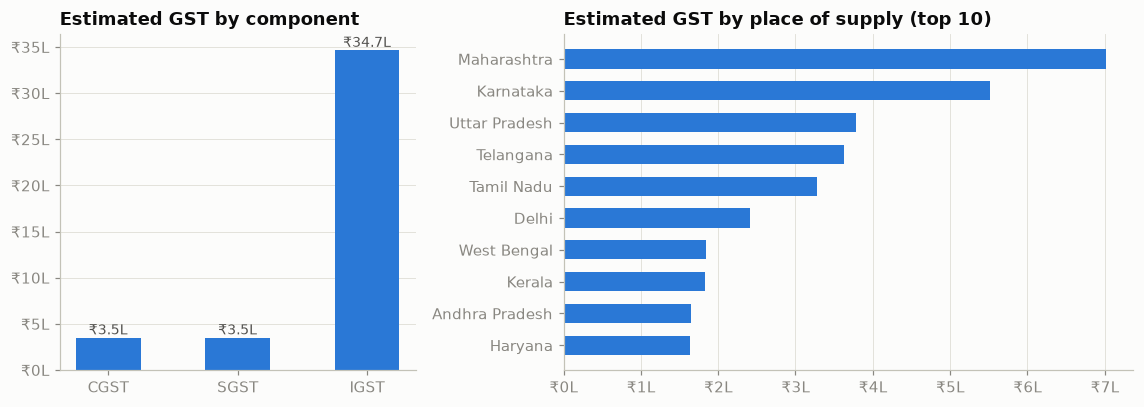

IGST share of total GST: 83.2%


,₹
CGST,"350,729.32"
SGST,"350,729.32"
IGST,"3,466,217.01"


In [11]:
split = pd.Series({"CGST": net.cgst.sum(), "SGST": net.sgst.sum(), "IGST": net.igst.sum()})
gst_state = net.groupby("ship_state").gst_amount.sum().sort_values(ascending=False).head(10).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), gridspec_kw={"width_ratios": [1, 1.6]})
axes[0].bar(split.index, split.values, color=BLUE, width=.5); axes[0].set_title("Estimated GST by component")
for x, v in enumerate(split.values): axes[0].text(x, v, f"₹{v/1e5:,.1f}L", ha="center", va="bottom", fontsize=9, color="#52514e")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(inr_lakh)); axes[0].grid(axis="x", visible=False)
axes[1].barh(gst_state.index.str.title(), gst_state.values, color=BLUE, height=.6)
axes[1].set_title("Estimated GST by place of supply (top 10)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(inr_lakh)); axes[1].grid(axis="y", visible=False)
fig.tight_layout(); fig.savefig(IMG / "05_gst.png"); plt.show()
print(f"IGST share of total GST: {split.IGST / split.sum() * 100:.1f}%")
split.to_frame("₹")

## 8. B2B vs B2C and sizes

In [12]:
b2b = net.groupby(net.is_b2b.map({True: "B2B", False: "B2C"})).agg(
    lines=("amount","size"), net_sales=("amount","sum"), avg_line_value=("amount","mean"))
size_order = ["XS","S","M","L","XL","XXL","3XL","4XL","5XL","6XL","Free"]
size = net.groupby("size").qty.sum().reindex(size_order).dropna()
display(b2b)
size.to_frame("units").T

,lines,net_sales,avg_line_value
is_b2b,,,
B2B,784,"550,127.00",701.69
B2C,104316,"69,110,531.00",662.51


size,XS,S,M,L,XL,XXL,3XL,4XL,5XL,6XL,Free
units,8956,13786,18366,18025,17143,14952,12440,367,474,647,328


## 9. Key findings & recommendations

Numbers below are produced by the cells above.

In [13]:
apr, jun = monthly.loc["2022-04"], monthly.loc["2022-06"]
findings = [
    f"Net sales of ₹{net.amount.sum()/1e7:.2f} crore from {net.order_id.nunique():,} orders (avg order value ₹{kpi['Avg order value (₹)']:,.0f}).",
    f"Sales per day fell {(1 - jun.sales_per_day / apr.sales_per_day) * 100:.1f}% from April to June — the trend needs attention.",
    f"'Set' and 'Kurta' bring in {cat.loc[['Set','Kurta'],'share_%'].sum():.1f}% of revenue — stock and ads should prioritise them.",
    f"Top 5 states (Maharashtra, Karnataka, Telangana, UP, Tamil Nadu) = {state['share_%'].head(5).sum():.1f}% of sales.",
    f"{kpi['Cancellation rate (%)']:.1f}% of order lines are cancelled; merchant-fulfilled orders cancel at {canc_by_fulfil['Merchant']:.1f}% vs {canc_by_fulfil['Amazon']:.1f}% for Amazon-fulfilled.",
    f"Estimated GST liability ₹{net.gst_amount.sum()/1e5:.1f} lakh; {slab.loc['5%','share_of_sales_%']:.1f}% of sales fall in the 5% slab and {split.IGST/split.sum()*100:.1f}% of GST is IGST (inter-state).",
]
for i, f in enumerate(findings, 1):
    print(f"{i}. {f}")

1. Net sales of ₹6.97 crore from 97,965 orders (avg order value ₹711).
2. Sales per day fell 15.2% from April to June — the trend needs attention.
3. 'Set' and 'Kurta' bring in 77.0% of revenue — stock and ads should prioritise them.
4. Top 5 states (Maharashtra, Karnataka, Telangana, UP, Tamil Nadu) = 56.4% of sales.
5. 14.2% of order lines are cancelled; merchant-fulfilled orders cancel at 17.5% vs 12.8% for Amazon-fulfilled.
6. Estimated GST liability ₹41.7 lakh; 79.5% of sales fall in the 5% slab and 83.2% of GST is IGST (inter-state).


**Recommendations**
1. **Cut merchant-side cancellations** — move top Set/Kurta SKUs to Amazon fulfilment (FBA), which cancels less.
2. **Investigate the April→June decline** — check stock-outs, pricing and ad spend for the top categories.
3. **Focus marketing on the top 5 states**, and test campaigns in fast-growing mid-size states.
4. **GST:** keep most products priced ≤ ₹1,000 per piece to stay in the 5% slab; because most GST is IGST, keep inter-state invoices and GSTR-1 state-wise data clean.

In [14]:
# Save the clean data used by SQL / Excel / dashboard
df.to_csv(ROOT / "data" / "processed" / "sales_clean.csv.gz", index=False, compression="gzip")
print("saved")

saved
